# Vector Operations: Scalar Multiplication, Sum and Dot Product of Vectors

In this lab you will use Python and `NumPy` functions to perform main vector operations: scalar multiplication, sum of vectors and their dot product. You will also investigate the speed of calculations using loop and vectorized forms of these main linear algebra operations

- investigate /ɪnˈves.tɪ.ɡeɪt/ 调查 / 探究 / 研究 指通过实验或分析来系统地观察、测量和比较，以发现规律或验证假设。在实验上下文中，这句话的意思是“你将通过使用循环形式和向量化形式来探究这些基本线性代数运算的计算速度差异”，即通过对比两种实现方式的耗时，亲自验证向量化计算的优势

# Table of Contents
- [ 1 - Scalar Multiplication and Sum of Vectors](#1)
  - [ 1.1 - Visualization of a Vector $v\in\mathbb{R}^2$](#1.1)
  - [ 1.2 - Scalar Multiplication](#1.2)
  - [ 1.3 - Sum of Vectors](#1.3)
  - [ 1.4 - Norm of a Vector](#1.4)
- [ 2 - Dot Product](#2)
  - [ 2.1 - Algebraic Definition of the Dot Product](#2.1)
  - [ 2.2 - Dot Product using Python](#2.2)
  - [ 2.3 - Speed of Calculations in Vectorized Form](#2.3)
  - [ 2.4 - Geometric Definition of the Dot Product](#2.4)
  - [ 2.5 - Application of the Dot Product: Vector Similarity](#2.5)

## Packages

Load the `NumPy` package to access its functions.

In [1]:
import numpy as np

<a name='1'></a>
## 1 - Scalar Multiplication and Sum of Vectors

<a name='1.1'></a>
### 1.1 - Visualization of a Vector $v\in\mathbb{R}^2$

You already have seen in the videos and labs, that vectors can be visualized as arrows, and it is easy to do it for a $v\in\mathbb{R}^2$, e.g.
$v=\begin{bmatrix}
          1 & 3
\end{bmatrix}^T$

The following code will show the visualization.

- $v \in \mathbb{R}^2$: 向量 $v$ 属于二维实数空间，表示向量 $v$ 是二维实数空间中的一个点或向量，即它包含 **2 个实数分量**，例如 $v = \begin{bmatrix} 1 \\ 3 \end{bmatrix}$。其中 $\mathbb{R}$ 代表实数集（Real numbers），上标 2 表示分量的个数（维度）。类似地，$\mathbb{R}^3$ 表示三维向量（3 个分量），$\mathbb{R}^n$ 表示 $n$ 维向量。在机器学习中，数据通常表示为高维向量，例如一张 $64 \times 64$ 的灰度图片可以展开为 $\mathbb{R}^{4096}$ 中的向量。

- `.item()`: NumPy 数组方法，用于将单个元素的 NumPy 数组或标量转换为 Python 原生数据类型（如 int、float、bool 等）。例如：
  - `np.array([1]).item()` 返回 Python 整数 `1`
  - `np.array([3.14]).item()` 返回 Python 浮点数 `3.14`
  - `np.array([[5]]).item()` 返回 Python 整数 `5`

在代码 `vx = v[0].item()` 中，`v[0]` 是形状为 `(1,)` 的 NumPy 数组 `[1]`，`.item()` 将其转换为 Python 原生 int 或 float，以便 `plt.quiver()` 和 `ax.text()` 能正确处理。

In [32]:
np_arr = np.array([1])
item_arr = np_arr[0]
item_ret = np_arr[0].item()
print(type(item_arr), item_arr.dtype, type(item_ret))

<class 'numpy.int64'> int64 <class 'int'>


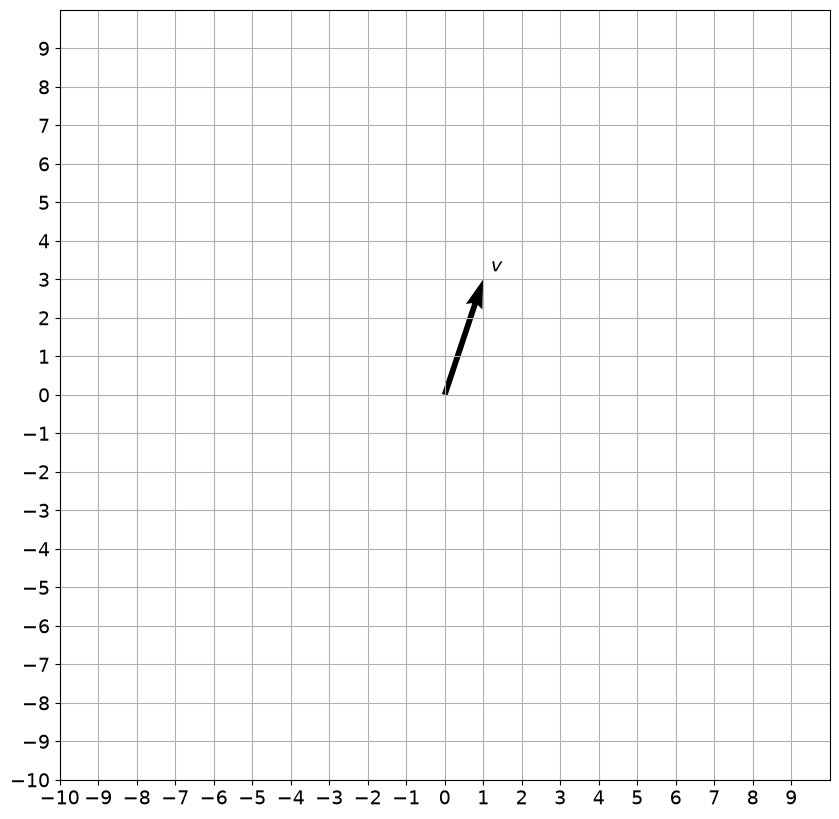

In [26]:
import matplotlib.pyplot as plt

"""
np.sign NumPy 符号函数 返回数组中每个元素的符号（sign），即：
- 如果元素 大于 0，返回 1
- 如果元素 等于 0，返回 0
- 如果元素 小于 0，返回 -1
"""

def plot_vectors(list_v, list_label, list_color):
    """
    在二维平面上绘制多个向量（箭头图）

    参数:
        list_v: 向量列表，每个向量为形状 (2, 1) 或 (2,) 的 NumPy 数组
        list_label: 每个向量对应的标签（如 "$v$", "$2v$"）
        list_color: 每个向量的颜色（如 "black", "red"）
    """

    # 创建图形和坐标轴，图形尺寸为 10x10 英寸
    # "_" 表示忽略返回的 Figure 对象，只取 Axes 对象
    _, ax = plt.subplots(figsize=(10, 10))

    # 设置 x 轴和 y 轴刻度标签的字体大小
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # 设置 x 轴和 y 轴的刻度范围为 -10 到 10 的整数
    ax.set_xticks(np.arange(-10, 10))
    ax.set_yticks(np.arange(-10, 10))

    # 设置坐标轴的显示范围：x 轴 -10 到 10，y 轴 -10 到 10
    plt.axis([-10, 10, -10, 10])

    # 遍历每个向量进行绘制
    for i, v in enumerate(list_v):
        # 提取向量的 x 和 y 分量，使用 .item() 将 NumPy 标量转换为 Python 原生 float
        # 这样 plt.quiver() 和 ax.text() 就能正确处理
        vx = v[0].item()
        vy = v[1].item()

        # 计算标签的偏移量，使标签不重叠在箭头上
        # np.sign(v) 返回每个分量的符号：-1, 0, 1
        # .flatten() 将数组展平为一维
        # 这里用 0.4 倍的符号作为偏移量
        sgn = 0.4 * np.sign(v).flatten()

        # 绘制箭头
        # 起点在原点 (0, 0)，终点在 (vx, vy)
        # color 指定颜色
        # angles='xy' 表示箭头角度与数据坐标一致
        # scale_units='xy' 表示箭头大小与数据单位一致
        # scale=1 表示不缩放
        plt.quiver(0, 0, vx, vy,
                   color=list_color[i],
                   angles='xy',
                   scale_units='xy',
                   scale=1)

        # 在箭头终点附近添加文本标签
        # vx - 0.2 + sgn[0].item() 计算标签位置的 x 坐标偏移
        # vy - 0.2 + sgn[1].item() 计算标签位置的 y 坐标偏移
        ax.text(vx - 0.2 + sgn[0].item(),
                vy - 0.2 + sgn[1].item(),
                list_label[i],
                fontsize=14,
                color=list_color[i])

    # 显示网格线
    plt.grid()

    # 设置坐标轴等比例缩放（保证圆形不被拉伸，保持箭头的真实角度）
    plt.gca().set_aspect("equal")

    # 在屏幕上显示图形
    plt.show()


# 测试代码：定义一个二维向量 v = (1, 3)，绘制并标注为 "$v$"
v = np.array([[1], [3]])
plot_vectors([v], [f"$v$"], ["black"])

The vector is defined by its **norm (length, magnitude)** and **direction**, not its actual position. But for clarity and convenience vectors are often plotted starting in the origin (in $\mathbb{R}^2$ it is a point $(0,0)$) .

- magnitude /ˈmæɡ.niːtud/ 大小 / 模长 / 幅度：指向量在空间中的长度，也称范数 (norm)。对于向量  
$v = (v_1, v_2, \dots, v_n)$，其 magnitude 定义为  
$\|v\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$  
即从原点到向量终点之间的距离。在实验中，`np.linalg.norm(v)` 计算的就是向量的 magnitude。它与方向 (direction) 共同构成向量的两个基本属性：magnitude 告诉你向量“有多长”，方向告诉你向量“朝哪走”。

<a name='1.2'></a>
### 1.2 - Scalar Multiplication

**Scalar multiplication** of a vector $v=\begin{bmatrix}
          v_1 & v_2 & \ldots & v_n 
\end{bmatrix}^T\in\mathbb{R}^n$ by a scalar $k$ is a vector $kv=\begin{bmatrix}
          kv_1 & kv_2 & \ldots & kv_n 
\end{bmatrix}^T$ (element by element multiplication). If $k>0$, then $kv$ is a vector pointing in the same direction as $v$ and it is $k$ times as long as $v$. If $k=0$, then $kv$ is a zero vector. If $k<0$, vector $kv$ will be pointing in the opposite direction. In Python you can perform this operation with a `*` operator. Check out the example below:

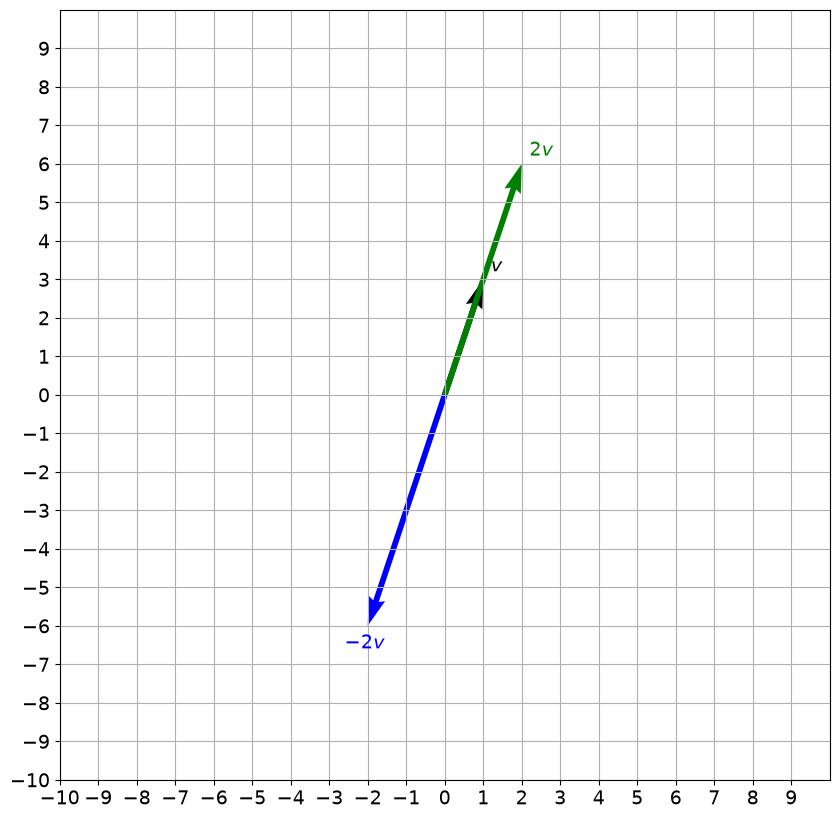

In [33]:
plot_vectors([v, 2*v, -2*v], [f"$v$", f"$2v$", f"$-2v$"], ["black", "green", "blue"])

<a name='1.3'></a>
### 1.3 - Sum of Vectors

**Sum of vectors (vector addition)** can be performed by adding the corresponding components of the vectors: if $v=\begin{bmatrix}
          v_1 & v_2 & \ldots & v_n 
\end{bmatrix}^T\in\mathbb{R}^n$ and  
$w=\begin{bmatrix}
          w_1 & w_2 & \ldots & w_n 
\end{bmatrix}^T\in\mathbb{R}^n$, then $v + w=\begin{bmatrix}
          v_1 + w_1 & v_2 + w_2 & \ldots & v_n + w_n 
\end{bmatrix}^T\in\mathbb{R}^n$. The so-called **parallelogram law** gives the rule for vector addition. For two vectors $u$ and $v$ represented by the adjacent sides (both in magnitude and direction) of a parallelogram drawn from a point, the vector sum $u+v$ is is represented by the diagonal of the parallelogram drawn from the same point:

<img src = "images/sum_of_vectors.png" width="230" align="middle"/>

In Python you can either use `+` operator or `NumPy` function `np.add()`. In the following code you can uncomment the line to check that the result will be the same:

- **parallelogram law** /ˌpær.əˈleɪ.ɡræm bɔː/ 平行四边形法则：指向量加法的几何规则：将两个向量 $u$ 和 $v$ 表示为从同一点出发的平行四边形两条邻边，则它们的和 $u + v$ 等于从该点出发的平行四边形的对角线。例如 $u = (1,3)$，$v = (4,-1)$，则 $u + v = (5,2)$，在图中就是两条箭头围成平行四边形的对角线。这个法则在实验中用于直观展示向量加法的几何意义，帮助理解向量叠加的“首尾相连”等价于“对角线合成”。

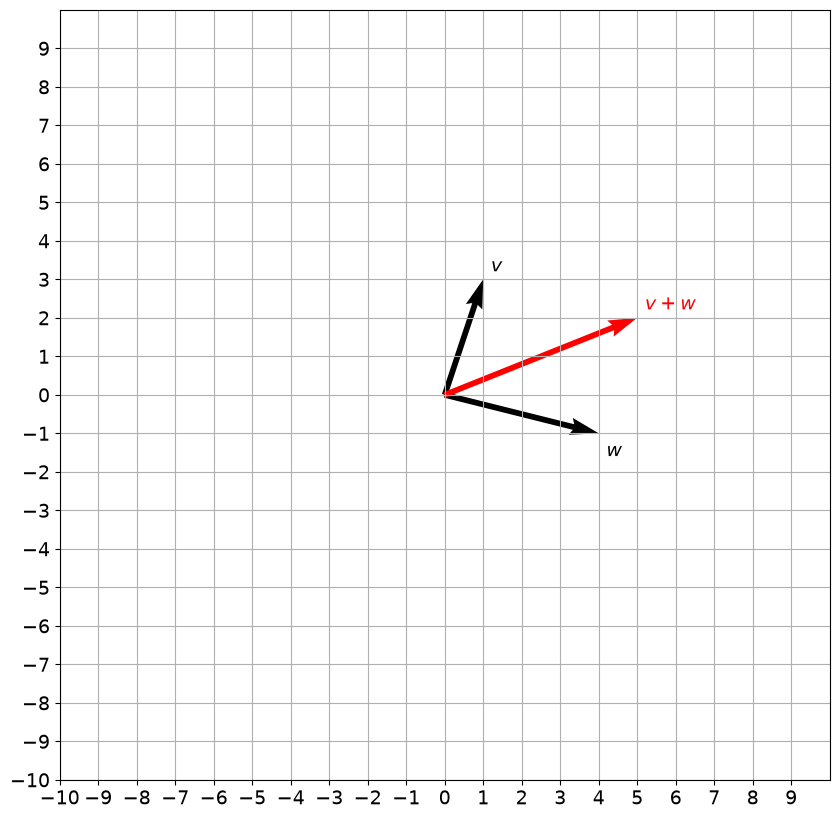

In [34]:
v = np.array([[1],[3]])
w = np.array([[4],[-1]])

plot_vectors([v, w, v + w], [f"$v$", f"$w$", f"$v + w$"], ["black", "black", "red"])
# plot_vectors([v, w, np.add(v, w)], [f"$v$", f"$w$", f"$v + w$"], ["black", "black", "red"])

<a name='1.4'></a>
### 1.4 - Norm of a Vector

The norm of a vector $v$ is denoted as $\lvert v\rvert$. It is a nonnegative number that describes the extent of the vector in space (its length). The norm of a vector can be found using `NumPy` function `np.linalg.norm()`:

- **extent** /ɪkˈstɛnt/ 程度 / 范围 / 大小：指向量在空间中延伸的“长度”或“规模”，与 magnitude（大小）、norm（范数）含义相近。在实验描述中，“its extent in space (its length)”就是在说向量的长度，即从原点到向量终点之间的距离。它是一个非负数，用于量化向量的规模。在机器学习中，向量的 extent 常用于归一化（将向量缩放到单位长度）或计算向量之间的距离。

In [36]:
print(v)

[[1]
 [3]]


In [35]:
print("Norm of a vector v is", np.linalg.norm(v))

Norm of a vector v is 3.1622776601683795


<a name='2'></a>
## 2 - Dot Product

<a name='2.1'></a>
### 2.1 - Algebraic Definition of the Dot Product

The **dot product** (or **scalar product**) is an algebraic operation that takes two vectors $x=\begin{bmatrix}
          x_1 & x_2 & \ldots & x_n 
\end{bmatrix}^T\in\mathbb{R}^n$ and  
$y=\begin{bmatrix}
          y_1 & y_2 & \ldots & y_n 
\end{bmatrix}^T\in\mathbb{R}^n$ and returns a single scalar. The dot product can be represented with a dot operator $x\cdot y$ and defined as:

$$x\cdot y = \sum_{i=1}^{n} x_iy_i = x_1y_1+x_2y_2+\ldots+x_ny_n \tag{1}$$

- scalar /ˈskeɪlə(r)/ 标量 / 纯量：指只有 **大小 (magnitude)** 而没有 **方向 (direction)** 的量

dot用于**判断“方向关系”（相似度 / 余弦相似度）**

这是点积最直观的几何意义：**两个向量方向越一致，点积越大；方向相反，点积为负；垂直时，点积为 0。**

- **用途**：这是搜索引擎、推荐系统（比如抖音/淘宝推荐）的基石。
- **原理**：把你的搜索词变成向量，把数据库里的文档也变成向量。点积越大，表示搜索词和这篇文档“方向越一致”（即越相关）。
- **公式**：
  $$
  u \cdot v = \|u\| \|v\| \cos \theta
  $$
  （点积隐含了夹角信息）。

In [43]:
myu = np.array([2, 3])
myv = np.array([-3, 2])
print(myu @ myv)

0


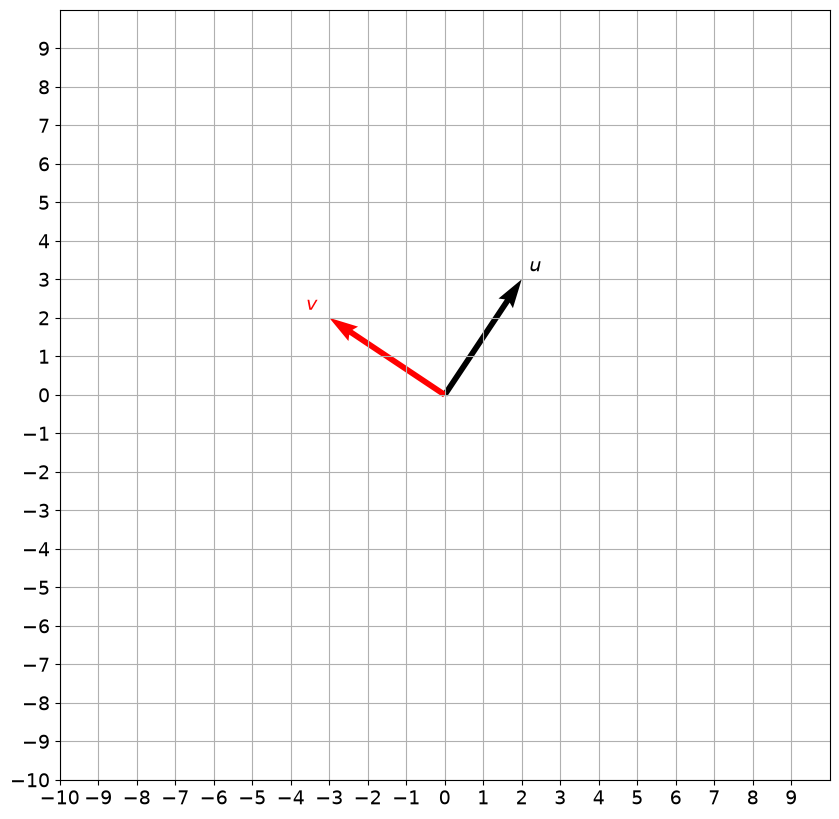

In [44]:
plot_vectors([myu, myv], [f"$u$", f"$v$"], ["black", "red"])

<a name='2.2'></a>
### 2.2 - Dot Product using Python

The simplest way to calculate dot product in Python is to take the sum of element by element multiplications. You can define the vectors $x$ and $y$ by listing their coordinates:

In [37]:
x = [1, -2, -5]
y = [4, 3, -1]

Next, let’s define a function `dot(x,y)` for the dot product calculation:

In [38]:
def dot(x, y):
    s=0
    for xi, yi in zip(x, y):
        s += xi * yi
    return s

For the sake of simplicity, let’s assume that the vectors passed to the above function are always of the same size, so that you don’t need to perform additional checks.

Now everything is ready to perform the dot product calculation calling the function `dot(x,y)`:

In [39]:
print("The dot product of x and y is", dot(x, y))

The dot product of x and y is 3


Dot product is very a commonly used operator, so `NumPy` linear algebra package provides quick way to calculate it using function `np.dot()`:

In [40]:
print("np.dot(x,y) function returns dot product of x and y:", np.dot(x, y)) 

np.dot(x,y) function returns dot product of x and y: 3


Note that you did not have to define vectors $x$ and $y$ as `NumPy` arrays, the function worked even with the lists. But there are alternative functions in Python, such as explicit operator `@` for the dot product, which can be applied only to the `NumPy` arrays. You can run the following cell to check that.

In [41]:
print("This line output is a dot product of x and y: ", np.array(x) @ np.array(y))

print("\nThis line output is an error:")
try:
    print(x @ y)
except TypeError as err:
    print(err)

This line output is a dot product of x and y:  3

This line output is an error:
unsupported operand type(s) for @: 'list' and 'list'


As both `np.dot()` and `@` operators are commonly used, it is recommended to define vectors as `NumPy` arrays to avoid errors. Let's redefine vectors $x$ and $y$ as `NumPy` arrays to be safe:

In [42]:
x = np.array(x)
y = np.array(y)

<a name='2.3'></a>
### 2.3 - Speed of Calculations in Vectorized Form

Dot product operations in Machine Learning applications are applied to the large vectors with hundreds or thousands of coordinates (called **high dimensional vectors**). Training models based on large datasets often takes hours and days even on powerful machines. Speed of calculations is crucial for the training and deployment of your models. 

It is important to understand the difference in the speed of calculations using vectorized and the loop forms of the vectors and functions. In the loop form operations are performed one by one, while in the vectorized form they can be performed in parallel. In the section above you defined loop version of the dot product calculation (function `dot()`), while `np.dot()` and `@` are the functions representing vectorized form.

Let's perform a simple experiment to compare their speed. Define new vectors $a$ and $b$ of the same size $1,000,000$:

In [ ]:
a = np.random.rand(1000000)
b = np.random.rand(1000000)

Use `time.time()` function to evaluate amount of time (in seconds) required to calculate dot product using the function `dot(x,y)` which you defined above: 

In [ ]:
import time

tic = time.time()
c = dot(a,b)
toc = time.time()
print("Dot product: ", c)
print ("Time for the loop version:" + str(1000*(toc-tic)) + " ms")

Now compare it with the speed of the vectorized versions:

In [ ]:
tic = time.time()
c = np.dot(a,b)
toc = time.time()
print("Dot product: ", c)
print ("Time for the vectorized version, np.dot() function: " + str(1000*(toc-tic)) + " ms")

In [ ]:
tic = time.time()
c = a @ b
toc = time.time()
print("Dot product: ", c)
print ("Time for the vectorized version, @ function: " + str(1000*(toc-tic)) + " ms")

You can see that vectorization is extremely beneficial in terms of the speed of calculations!

<a name='2.4'></a>
### 2.4 - Geometric Definition of the Dot Product

In [Euclidean space](https://en.wikipedia.org/wiki/Euclidean_space), a Euclidean vector has both magnitude and direction. The dot product of two vectors $x$ and $y$ is defined by:

$$x\cdot y = \lvert x\rvert \lvert y\rvert \cos(\theta),\tag{2}$$

where $\theta$ is the angle between the two vectors:

<img src = "images/dot_product_geometric.png" width="230" align="middle"/>

This provides an easy way to test the orthogonality between vectors. If $x$ and $y$ are orthogonal (the angle between vectors is $90^{\circ}$), then since $\cos(90^{\circ})=0$, it implies that **the dot product of any two orthogonal vectors must be $0$**. Let's test it, taking two vectors $i$ and $j$ we know are orthogonal:

In [ ]:
i = np.array([1, 0, 0])
j = np.array([0, 1, 0])
print("The dot product of i and j is", dot(i, j))

<a name='2.5'></a>
### 2.5 - Application of the Dot Product: Vector Similarity

Geometric definition of a dot product is used in one of the applications - to evaluate **vector similarity**. In Natural Language Processing (NLP) words or phrases from vocabulary are mapped to a corresponding vector of real numbers. Similarity between two vectors can be defined as a cosine of the angle between them. When they point in the same direction, their similarity is 1 and it decreases with the increase of the angle. 

Then equation $(2)$ can be rearranged to evaluate cosine of the angle between vectors:

$\cos(\theta)=\frac{x \cdot y}{\lvert x\rvert \lvert y\rvert}.\tag{3}$

Zero value corresponds to the zero similarity between vectors (and words corresponding to those vectors). Largest value is when vectors point in the same direction, lowest value is when vectors point in the opposite directions.

This example of vector similarity is given to link the material with the Machine Learning applications. There will be no actual implementation of it in this Course. Some examples of implementation can be found in the Natual Language Processing Specialization.

Well done, you have finished this lab!